# CDE Mean Distributions

This notebook produces three figures for all supported protein families:
1. **CDE distribution** — histogram of the mean CDE of the initial segment across all timescales, with 40th/60th percentile thresholds.
2. **CDE vs Energy scatter** — Pearson correlation between mean CDE and bmDCA energy of the initial segment.
3. **Hamming distance distributions** — mirrored histograms of the start-to-mid Hamming distance per timescale (Chorismate Mutase only).

## Setup

Import libraries, resolve the paper directory, set global constants (timescales, sequence cap, dtype), and define the three protein families with their data directories.

In [1]:
from pathlib import Path
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import pearsonr

from adabmDCA.dataset import DatasetDCA
from adabmDCA.fasta import get_tokens
from adabmDCA.functional import one_hot
from adabmDCA.io import load_params
from adabmDCA.statmech import compute_energy


def resolve_paper_dir():
    """Return the paper_notebooks directory when run from the notebook folder or repo root."""
    cwd = Path.cwd()
    if (cwd / "generated_data").exists():
        return cwd
    if (cwd / "paper_notebooks" / "generated_data").exists():
        return cwd / "paper_notebooks"
    raise FileNotFoundError("Could not locate the paper_notebooks/generated_data directory.")


paper_dir = resolve_paper_dir()
output_path = paper_dir / "immagini_paper" / "cde_plot"
output_path.mkdir(parents=True, exist_ok=True)

timescales = ["10e1", "10e2", "10e3", "10e4", "10e5", "10e6"]
n_seqs = 20_000
percentile = 0.4
dtype = torch.float32
device = torch.device("cpu")
data_type = "ACDEFGHIKLMNPQRSTVWY-"
tokens = get_tokens(data_type)
q = len(tokens)

families = [
    {
        "label": "Chorismate Mutase",
        "data_dir": "CM",
        "model_dir": "CM",
        "color": "C0",
    },
    {
        "label": "Beta-Lactamase",
        "data_dir": "betalactamase",
        "model_dir": "betalactamase",
        "color": "C1",
    },
    {
        "label": "RR domain",
        "data_dir": "PF00072_2nd",
        "model_dir": "PF00072",
        "color": "C2",
    },
]

In [2]:
def load_cde_mean(cde_file, timescales=timescales, n_seqs=n_seqs, dtype=dtype):
    cde_file = Path(cde_file)
    if not cde_file.exists():
        raise FileNotFoundError(f"CDE file not found: {cde_file}")

    loaded = np.load(cde_file, allow_pickle=True).item()
    missing = [key for key in timescales if key not in loaded]
    if missing:
        raise KeyError(f"Missing timescales in {cde_file}: {missing}")

    cde = {}
    for key in timescales:
        values = np.asarray(loaded[key])
        if values.shape[0] < n_seqs:
            raise ValueError(
                f"CDE file {cde_file} for {key} has only {values.shape[0]} values, "
                f"but {n_seqs} values were requested."
            )
        cde[key] = torch.as_tensor(values[:n_seqs], dtype=dtype)
    return cde


cde_by_family = {}
summary_rows = []

for family in families:
    cde_file = paper_dir / "generated_data" / family["data_dir"] / "full_cde_test" / "CDE_0_mean.npy"
    CDE_0_mean = load_cde_mean(cde_file)
    CDE_0_mean_tot = torch.cat([CDE_0_mean[t] for t in timescales])

    percentile_low = torch.quantile(CDE_0_mean_tot, percentile).item()
    percentile_high = torch.quantile(CDE_0_mean_tot, 1 - percentile).item()
    median = torch.quantile(CDE_0_mean_tot, 0.5).item()

    cde_by_family[family["label"]] = {
        "by_timescale": CDE_0_mean,
        "values": CDE_0_mean_tot,
        "percentile_low": percentile_low,
        "percentile_high": percentile_high,
        "color": family["color"],
    }

    summary_rows.append(
        {
            "Family": family["label"],
            f"{int(percentile * 100)}th percentile": percentile_low,
            f"{int((1 - percentile) * 100)}th percentile": percentile_high,
            "Percentile range": percentile_high - percentile_low,
            "Minimum": CDE_0_mean_tot.min().item(),
            "Maximum": CDE_0_mean_tot.max().item(),
            "Mean": CDE_0_mean_tot.mean().item(),
            "Median": median,
            "N": CDE_0_mean_tot.numel(),
        }
    )

summary = pd.DataFrame(summary_rows)
summary.to_csv(output_path / "CDE_mean_distribution_summary.csv", index=False)
summary

,Family,40th percentile,60th percentile,Percentile range,Minimum,Maximum,Mean,Median,N
0,Chorismate Mutase,1.786780,1.977229,0.190449,0.954426,2.904616,1.886635,1.882984,120000
1,Beta-Lactamase,2.269840,2.580508,0.310669,1.493935,3.082647,2.401563,2.465232,120000
2,RR domain,2.346782,2.469915,0.123133,1.715851,2.829762,2.393718,2.410385,120000


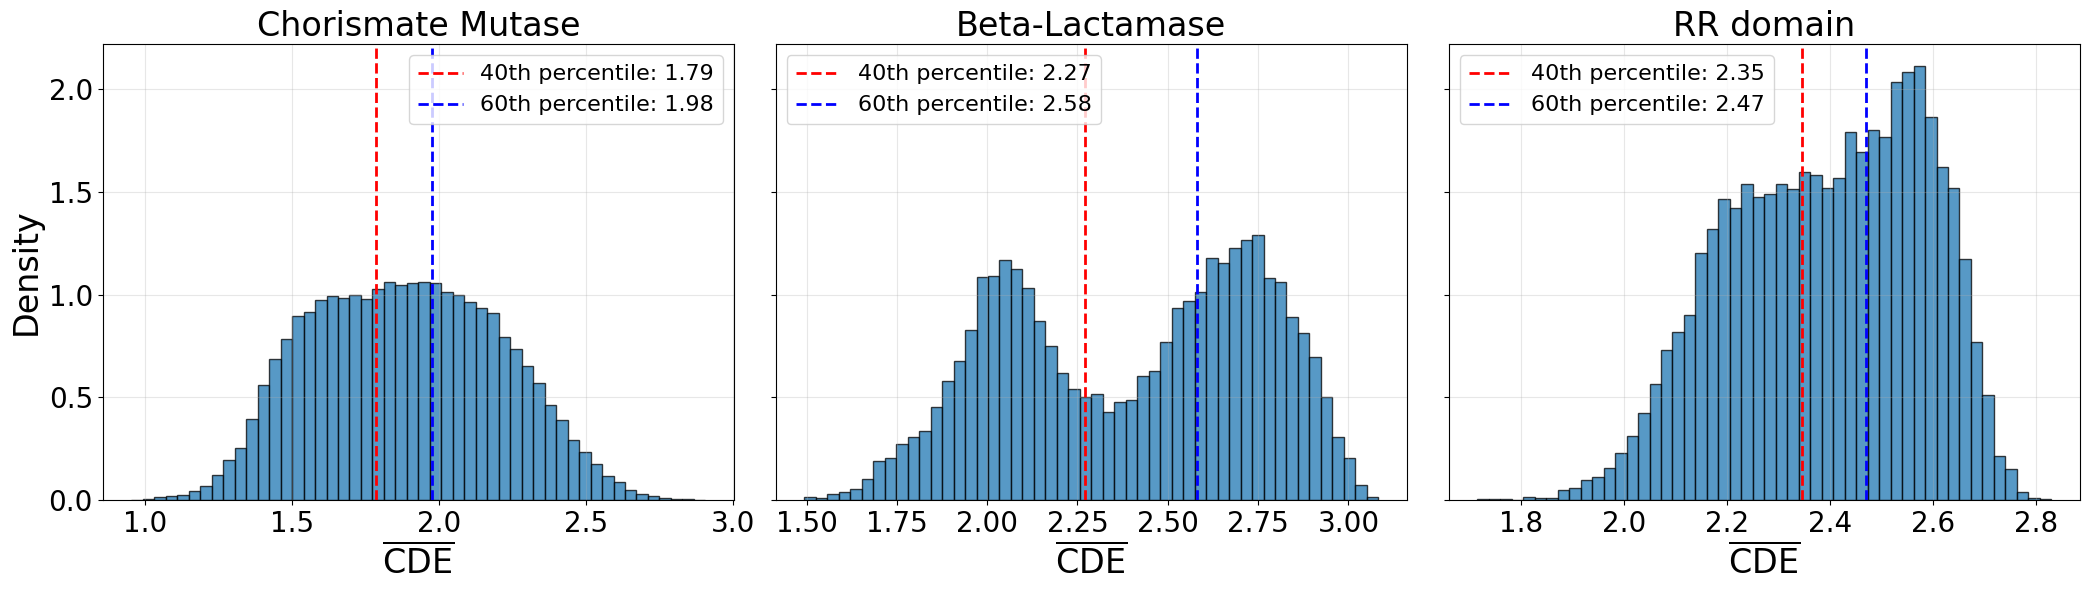

Saved figure to: /home/robertonetti/Desktop/Github/gen-path/paper_notebooks/immagini_paper/cde_plot/CDE_mean_distribution_all_families.pdf


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)

for ax, (family_label, info) in zip(axes, cde_by_family.items()):
    values = info["values"]
    percentile_low = info["percentile_low"]
    percentile_high = info["percentile_high"]

    ax.hist(values.cpu().numpy(), bins=50, density=True, edgecolor="black", alpha=0.75, color="C0")
    ax.axvline(
        percentile_low,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"{int(percentile * 100)}th percentile: {percentile_low:.2f}",
    )
    ax.axvline(
        percentile_high,
        color="blue",
        linestyle="--",
        linewidth=2,
        label=f"{int((1 - percentile) * 100)}th percentile: {percentile_high:.2f}",
    )

    ax.set_title(family_label, fontsize=24)
    ax.set_xlabel(r"$\overline{\mathrm{CDE}}$", fontsize=24)
    if ax == axes[0]:
        ax.set_ylabel("Density", fontsize=24)
    ax.tick_params(axis="both", labelsize=20)
    ax.legend(fontsize=16)
    ax.grid(alpha=0.3)

fig.tight_layout()
figure_path = output_path / "CDE_mean_distribution_all_families.pdf"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {figure_path}")

## CDE vs Energy Pearson

Load the test data corresponding to each `CDE_0_mean` array, compute the bmDCA energy of the matching `T=0` segment with the corresponding family model, and plot CDE-energy Pearson scatter plots.

In [4]:
def compute_family_cde_energy(family, cde_info, chunk_size=2048):
    data_dir = paper_dir / "generated_data" / family["data_dir"]
    model_file = paper_dir / "evolution_bmDCA_model" / family["model_dir"] / "params.dat"
    if not model_file.exists():
        raise FileNotFoundError(f"Model file not found: {model_file}")

    model = load_params(model_file, tokens=tokens, device=device, dtype=dtype)
    model_device = {
        "bias": model["bias"].to(device),
        "coupling_matrix": model["coupling_matrix"].to(device),
    }

    cde_values = []
    energy_values = []
    rows = []

    for t in timescales:
        fasta_file = data_dir / f"{t}_test.fasta"
        if not fasta_file.exists():
            raise FileNotFoundError(f"Dataset file not found: {fasta_file}")

        ds = DatasetDCA(
            path_data=fasta_file,
            alphabet=data_type,
            device=device,
            dtype=dtype,
            no_reweighting=True,
        )
        data = ds.data[:n_seqs]
        L = data.shape[1] // 3
        cde_t = cde_info["by_timescale"][t][: data.shape[0]]
        energies_t = []

        with torch.no_grad():
            for start in range(0, data.shape[0], chunk_size):
                end = min(start + chunk_size, data.shape[0])
                segment_oh = one_hot(data[start:end, :L], num_classes=q).to(dtype=dtype).to(device)
                energies_t.append(compute_energy(segment_oh, model_device).cpu())
                del segment_oh

        energies_t = torch.cat(energies_t)
        if energies_t.numel() != cde_t.numel():
            raise ValueError(
                f"Length mismatch for {family['label']} {t}: "
                f"{cde_t.numel()} CDE values vs {energies_t.numel()} energy values."
            )

        cde_values.append(cde_t.cpu())
        energy_values.append(energies_t)
        rows.append(
            {
                "Family": family["label"],
                "Timescale": t,
                "N": int(cde_t.numel()),
                "Mean CDE": float(cde_t.mean()),
                "Mean energy": float(energies_t.mean()),
                "Pearson r": pearsonr(cde_t.numpy(), energies_t.numpy()).statistic,
            }
        )

        del ds, data, energies_t
        gc.collect()

    cde_all = torch.cat(cde_values)
    energy_all = torch.cat(energy_values)
    return {
        "cde": cde_all,
        "energy": energy_all,
        "summary": rows,
    }


cde_energy_by_family = {}
energy_summary_rows = []

for family in families:
    result = compute_family_cde_energy(family, cde_by_family[family["label"]])
    cde_energy_by_family[family["label"]] = {
        **result,
        "color": family["color"],
    }
    energy_summary_rows.extend(result["summary"])

energy_summary = pd.DataFrame(energy_summary_rows)
energy_summary.to_csv(output_path / "CDE_energy_by_timescale_summary.csv", index=False)
energy_summary

Multi-sequence alignment imported: M = 29943, L = 288, q = 21, M_eff = 29943.
Multi-sequence alignment imported: M = 30000, L = 288, q = 21, M_eff = 30000.
Multi-sequence alignment imported: M = 30000, L = 288, q = 21, M_eff = 30000.
Multi-sequence alignment imported: M = 30000, L = 288, q = 21, M_eff = 30000.
Multi-sequence alignment imported: M = 30000, L = 288, q = 21, M_eff = 30000.
Multi-sequence alignment imported: M = 20000, L = 288, q = 21, M_eff = 20000.
Multi-sequence alignment imported: M = 20000, L = 597, q = 21, M_eff = 20000.
Multi-sequence alignment imported: M = 20000, L = 597, q = 21, M_eff = 20000.
Multi-sequence alignment imported: M = 20000, L = 597, q = 21, M_eff = 20000.
Multi-sequence alignment imported: M = 20000, L = 597, q = 21, M_eff = 20000.
Multi-sequence alignment imported: M = 20000, L = 597, q = 21, M_eff = 20000.
Multi-sequence alignment imported: M = 20000, L = 597, q = 21, M_eff = 20000.
Multi-sequence alignment imported: M = 20000, L = 336, q = 21, M

,Family,Timescale,N,Mean CDE,Mean energy,Pearson r
0,Chorismate Mutase,10e1,20000,1.882341,137.450500,0.950142
1,Chorismate Mutase,10e2,20000,1.885700,137.742523,0.949211
2,Chorismate Mutase,10e3,20000,1.887164,137.780350,0.950462
3,Chorismate Mutase,10e4,20000,1.883618,137.576614,0.950145
4,Chorismate Mutase,10e5,20000,1.886811,137.685623,0.950006
5,Chorismate Mutase,10e6,20000,1.894174,138.322250,0.951139
6,Beta-Lactamase,10e1,20000,2.401563,345.975586,0.968243
7,Beta-Lactamase,10e2,20000,2.401563,345.975586,0.968243
8,Beta-Lactamase,10e3,20000,2.401563,345.975586,0.968243
9,Beta-Lactamase,10e4,20000,2.401563,345.975586,0.968243


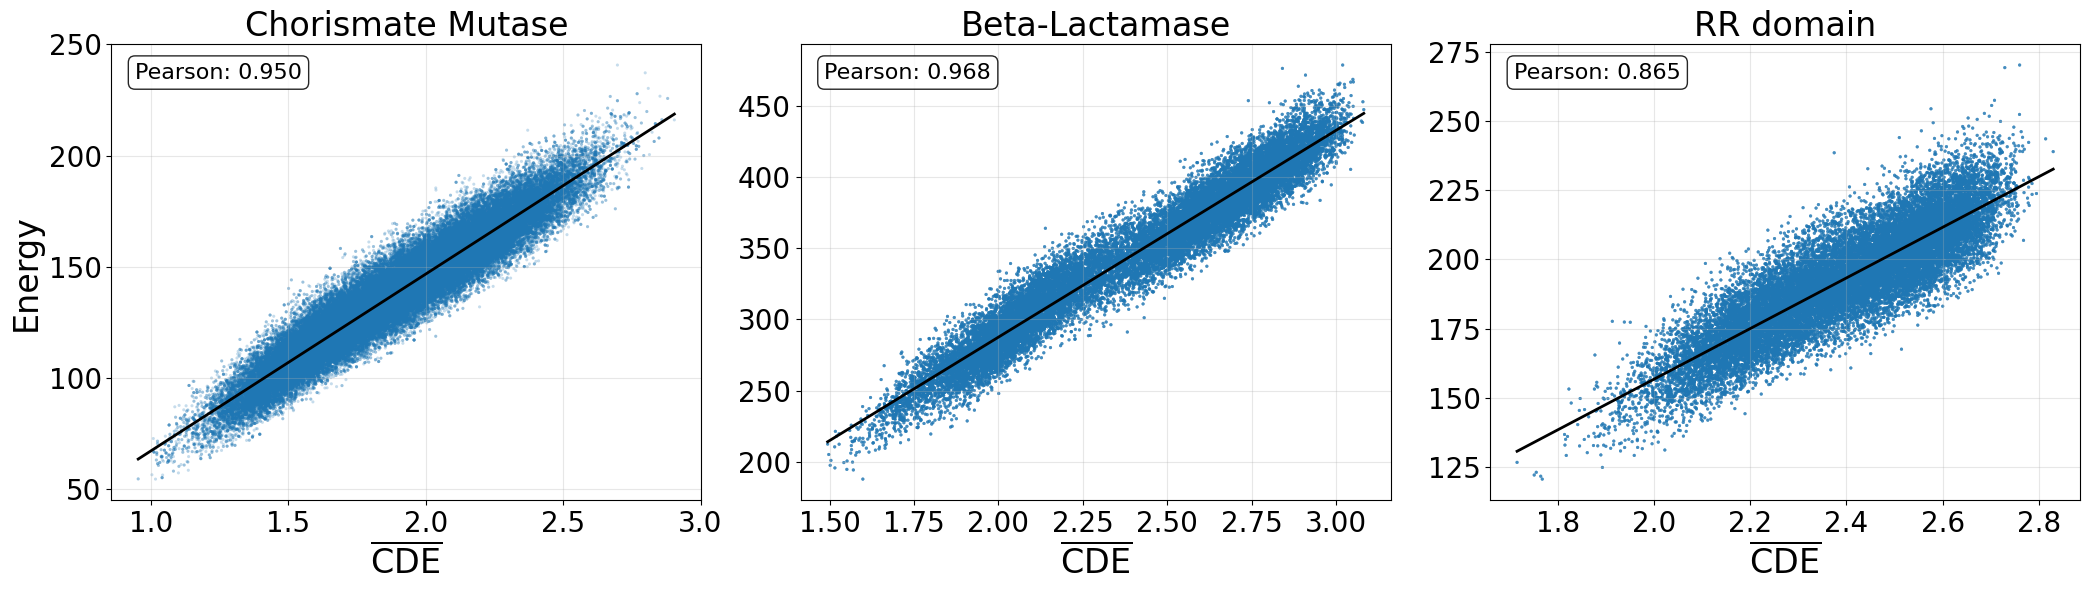

Saved figure to: /home/robertonetti/Desktop/Github/gen-path/paper_notebooks/immagini_paper/cde_plot/CDE_vs_energy_pearson_all_families.png


,Family,Pearson r,p-value
0,Chorismate Mutase,0.950195,0.0
1,Beta-Lactamase,0.968243,0.0
2,RR domain,0.865059,0.0


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=False)

pearson_rows = []
for ax, (family_label, info) in zip(axes, cde_energy_by_family.items()):
    cde = info["cde"].numpy()
    energy = info["energy"].numpy()
    pearson = pearsonr(cde, energy)
    pearson_rows.append(
        {
            "Family": family_label,
            "Pearson r": pearson.statistic,
            "p-value": pearson.pvalue,
        }
    )

    ax.scatter(cde, energy, s=5, alpha=0.25, color="C0", edgecolors="none")
    slope, intercept = np.polyfit(cde, energy, deg=1)
    x_fit = np.linspace(cde.min(), cde.max(), 200)
    ax.plot(x_fit, slope * x_fit + intercept, color="black", linewidth=2)
    ax.set_title(family_label, fontsize=24)
    ax.text(
        0.04,
        0.96,
        f"Pearson: {pearson.statistic:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=16,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "black", "alpha": 0.85},
    )
    ax.set_xlabel(r"$\overline{\mathrm{CDE}}$", fontsize=24)
    if ax == axes[0]:
        ax.set_ylabel("Energy", fontsize=24)
    ax.tick_params(axis="both", labelsize=20)
    ax.grid(alpha=0.3)

fig.tight_layout()
figure_path = output_path / "CDE_vs_energy_pearson_all_families.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

pearson_summary = pd.DataFrame(pearson_rows)
pearson_summary.to_csv(output_path / "CDE_vs_energy_pearson_summary.csv", index=False)
print(f"Saved figure to: {figure_path}")
pearson_summary

## Chorismate Mutase T0-T Distance Distributions

Compute the Hamming distance between the first and second third of each Chorismate Mutase test sequence, timescale by timescale, and plot the resulting distributions.

In [6]:
cm_distance_by_timescale = {}
cm_data_dir = paper_dir / "generated_data" / "CM"

for t in timescales:
    fasta_file = cm_data_dir / f"{t}_test.fasta"
    if not fasta_file.exists():
        raise FileNotFoundError(f"Dataset file not found: {fasta_file}")

    ds = DatasetDCA(
        path_data=fasta_file,
        alphabet=data_type,
        device=device,
        dtype=dtype,
        no_reweighting=True,
    )
    data = ds.data[:n_seqs]
    L = data.shape[1] // 3
    distances = (data[:, :L] != data[:, L:2 * L]).sum(dim=1).cpu().numpy()
    cm_distance_by_timescale[t] = distances

    del ds, data
    gc.collect()

Multi-sequence alignment imported: M = 29943, L = 288, q = 21, M_eff = 29943.
Multi-sequence alignment imported: M = 30000, L = 288, q = 21, M_eff = 30000.
Multi-sequence alignment imported: M = 30000, L = 288, q = 21, M_eff = 30000.
Multi-sequence alignment imported: M = 30000, L = 288, q = 21, M_eff = 30000.
Multi-sequence alignment imported: M = 30000, L = 288, q = 21, M_eff = 30000.
Multi-sequence alignment imported: M = 20000, L = 288, q = 21, M_eff = 20000.


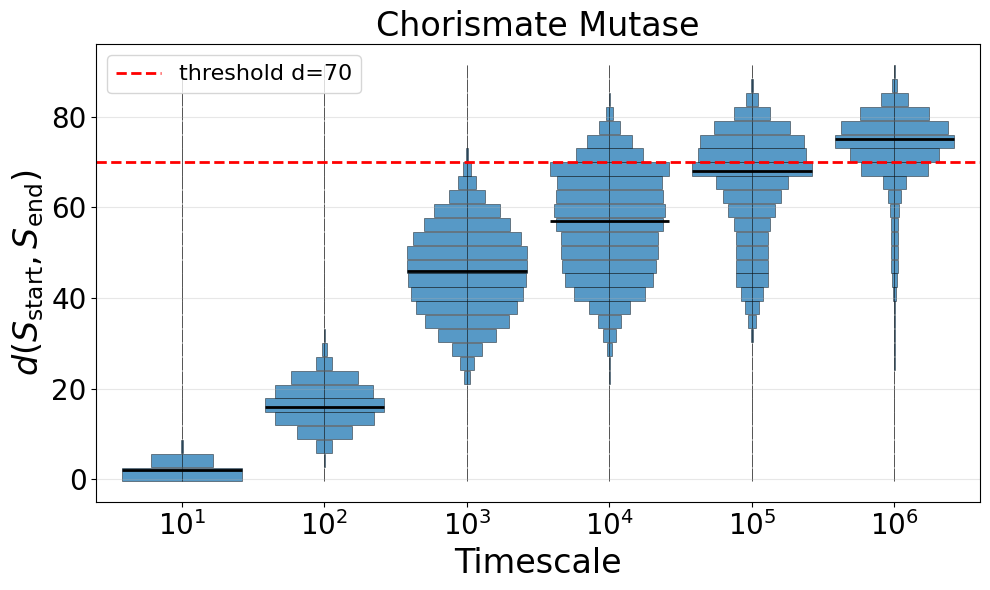

Saved figure to: /home/robertonetti/Desktop/Github/gen-path/paper_notebooks/immagini_paper/cde_plot/CM_first_second_third_distance_mirrored_histograms.pdf


In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
all_distances = np.concatenate([cm_distance_by_timescale[t] for t in timescales])
n_bins = 30
bins = np.linspace(all_distances.min() - 0.5, all_distances.max() + 0.5, n_bins + 1)
max_width = 0.42

for x_pos, t in enumerate(timescales):
    counts, edges = np.histogram(cm_distance_by_timescale[t], bins=bins, density=True)
    widths = counts / counts.max() * max_width if counts.max() > 0 else counts
    centers = 0.5 * (edges[:-1] + edges[1:])
    heights = np.diff(edges) * 0.95

    ax.barh(
        centers,
        widths,
        height=heights,
        left=x_pos,
        align="center",
        color="C0",
        edgecolor="black",
        alpha=0.75,
        linewidth=0.4,
    )
    ax.barh(
        centers,
        -widths,
        height=heights,
        left=x_pos,
        align="center",
        color="C0",
        edgecolor="black",
        alpha=0.75,
        linewidth=0.4,
    )

    median = np.median(cm_distance_by_timescale[t])
    ax.hlines(median, x_pos - max_width, x_pos + max_width, color="black", linewidth=2)

ax.axhline(70, color="red", linestyle="--", linewidth=2, label="threshold d=70")
ax.set_xlim(-0.6, len(timescales) - 0.4)
ax.set_xticks(np.arange(len(timescales)))
ax.set_xticklabels([rf"$10^{{{t.split('e')[1]}}}$" for t in timescales], fontsize=20)
# ax.set_xticklabels(timescales, fontsize=20)
ax.set_xlabel("Timescale", fontsize=24)
ax.set_ylabel(r"$d(S_\mathrm{start}, S_\mathrm{end})$", fontsize=24)
ax.set_title("Chorismate Mutase", fontsize=24)
ax.tick_params(axis="y", labelsize=20)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=16, loc="upper left")
fig.tight_layout()
figure_path = output_path / "CM_first_second_third_distance_mirrored_histograms.pdf"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {figure_path}")